# Laboratorio #5 – Análisis de tráfico de red



In [1]:
from scapy.all import rdpcap, IP, TCP, UDP, DNS, Raw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

---
## Parte 1 – Análisis de paquetes
### Testeo de la herramienta
#### 1. Tipo de datos, longitud y contenido del pcap (primeros 10 paquetes)

In [2]:
PCAP_FILE = "analisis_paquetes.pcap"
packets = rdpcap(PCAP_FILE)
sample = packets[:10]

pd.DataFrame([
    {"#": i + 1, "Tipo": type(pkt).__name__, "Longitud (bytes)": len(pkt), "Resumen": pkt.summary()}
    for i, pkt in enumerate(sample)
])

,#,Tipo,Longitud (bytes),Resumen
0,1,Ether,975,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
1,2,Ether,98,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
2,3,Ether,989,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
3,4,Ether,98,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
4,5,Ether,1026,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
5,6,Ether,98,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
6,7,Ether,1012,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
7,8,Ether,98,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
8,9,Ether,1017,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
9,10,Ether,98,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...


El pcap es de tipo `PacketList` y contiene **62 paquetes** en total. Los primeros 10 son paquetes UDP sobre DNS — se observan tanto consultas (`Qry`) como respuestas (`Ans`).

#### 2. Src Address, Dst Address, Src Port, Dst Port

In [3]:
rows_sample = []
for pkt in sample:
    if IP in pkt:
        src_port = dst_port = None
        if TCP in pkt:
            src_port, dst_port = pkt[TCP].sport, pkt[TCP].dport
        elif UDP in pkt:
            src_port, dst_port = pkt[UDP].sport, pkt[UDP].dport
        rows_sample.append({
            "Src Address": pkt[IP].src,
            "Dst Address": pkt[IP].dst,
            "Src Port"   : src_port,
            "Dst Port"   : dst_port,
        })

pd.DataFrame(rows_sample)

,Src Address,Dst Address,Src Port,Dst Port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
5,84.54.22.33,10.1.10.53,53,53
6,10.1.10.53,84.54.22.33,53,53
7,84.54.22.33,10.1.10.53,53,53
8,10.1.10.53,84.54.22.33,53,53
9,84.54.22.33,10.1.10.53,53,53


---
### Estadísticas y detección con Z-Score
#### 1 & 2. Cargar el pcap completo y convertir a DataFrame

In [4]:
def build_dataframe(pkts):
    rows = []
    for pkt in pkts:
        if IP not in pkt:
            continue
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst
        pkt_len = len(pkt)
        src_port = dst_port = None
        payload_len = 0
        payload_raw = b""
        if TCP in pkt:
            src_port, dst_port = pkt[TCP].sport, pkt[TCP].dport
            if Raw in pkt:
                payload_raw = pkt[Raw].load
                payload_len = len(payload_raw)
        elif UDP in pkt:
            src_port, dst_port = pkt[UDP].sport, pkt[UDP].dport
            if DNS in pkt:
                payload_raw = bytes(pkt[UDP].payload)
                payload_len = len(payload_raw)
            elif Raw in pkt:
                payload_raw = pkt[Raw].load
                payload_len = len(payload_raw)
        rows.append({
            "src_ip"     : src_ip,
            "dst_ip"     : dst_ip,
            "src_port"   : src_port,
            "dst_port"   : dst_port,
            "pkt_len"    : pkt_len,
            "payload_len": payload_len,
            "payload_raw": payload_raw,
        })
    return pd.DataFrame(rows)

df = build_dataframe(packets)
df.drop(columns='payload_raw').head(10)

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len
0,10.1.10.53,84.54.22.33,53,53,975,933
1,84.54.22.33,10.1.10.53,53,53,98,56
2,10.1.10.53,84.54.22.33,53,53,989,947
3,84.54.22.33,10.1.10.53,53,53,98,56
4,10.1.10.53,84.54.22.33,53,53,1026,984
5,84.54.22.33,10.1.10.53,53,53,98,56
6,10.1.10.53,84.54.22.33,53,53,1012,970
7,84.54.22.33,10.1.10.53,53,53,98,56
8,10.1.10.53,84.54.22.33,53,53,1017,975
9,84.54.22.33,10.1.10.53,53,53,98,56


El DataFrame tiene **62 filas × 7 columnas**. Se conserva `payload_raw` (bytes crudos) para la inspección manual posterior.

#### 3. Estadísticas básicas
##### 3a. IP origen más frecuente

In [5]:
top_src = df['src_ip'].value_counts()
most_freq_src = top_src.idxmax()
top_src

src_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La IP origen más frecuente es **`10.1.10.53`** con 31 paquetes enviados.

##### 3b. IP destino más frecuente

In [6]:
top_dst = df['dst_ip'].value_counts()
most_freq_dst = top_dst.idxmax()
top_dst

dst_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La IP destino más frecuente es **`10.1.10.53`** con 31 paquetes recibidos.

##### 3c. IPs con las que se comunica `10.1.10.53`

In [7]:
df[df['src_ip'] == most_freq_src]['dst_ip'].value_counts()

dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

##### 3d. Puertos destino usados por `10.1.10.53`

In [8]:
df[df['src_ip'] == most_freq_src]['dst_port'].value_counts()

dst_port
53    31
Name: count, dtype: int64

##### 3e. Puertos origen en comunicaciones hacia `10.1.10.53`

In [9]:
df[df['dst_ip'] == most_freq_dst]['src_port'].value_counts()

src_port
53    31
Name: count, dtype: int64

##### 3f. Propósito de los puertos más frecuentes

El puerto predominante en ambos incisos es el **puerto 53 (UDP/TCP) → DNS** (*Domain Name System*).

DNS es el servicio que resuelve nombres de dominio a direcciones IP (ej. `google.com` → `142.250.x.x`). Al ser un protocolo esencial, está casi universalmente **permitido en firewalls y proxies corporativos**, lo que lo convierte en un vector atractivo para técnicas de evasión como el *DNS tunneling*.

---
#### 4. Z-Score sobre el tamaño de payload
##### 4a. Z-Score calculado con estadísticas del propio pcap

In [10]:
mean_pl = df['payload_len'].mean()
std_pl  = df['payload_len'].std()
df['zscore_pcap'] = (df['payload_len'] - mean_pl) / std_pl

anom_2 = df[df['zscore_pcap'].abs() > 2][['src_ip','dst_ip','payload_len','zscore_pcap']]
anom_3 = df[df['zscore_pcap'].abs() > 3][['src_ip','dst_ip','payload_len','zscore_pcap']]

from IPython.display import display
display(anom_2)
anom_3

,src_ip,dst_ip,payload_len,zscore_pcap


,src_ip,dst_ip,payload_len,zscore_pcap


**No se detectaron paquetes anómalos** con ninguno de los umbrales (|Z| > 2 ni |Z| > 3).

Los valores de referencia calculados desde el propio pcap son **media ≈ 481 bytes** y **desviación estándar ≈ 460 bytes** — cifras tan amplias que ningún valor queda a más de 2 desviaciones. El motivo se explica en el histograma siguiente.

##### 4b. Histograma de `payload_len`

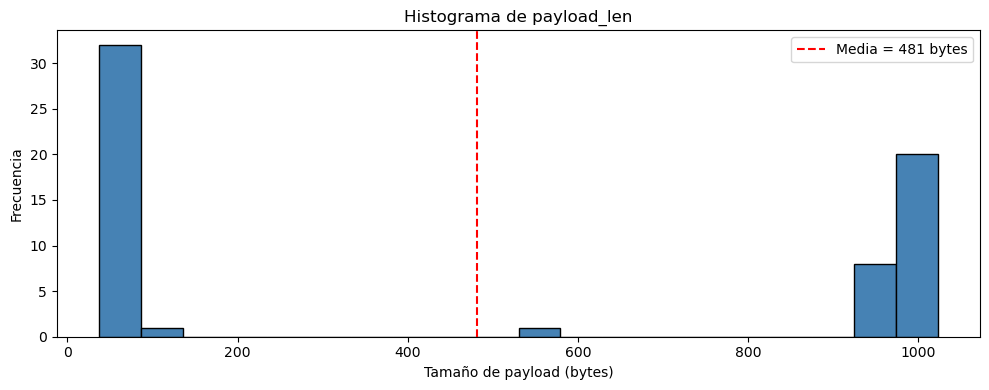

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['payload_len'], bins=20, color='steelblue', edgecolor='black')
ax.axvline(mean_pl, color='red', linestyle='--', label=f'Media = {mean_pl:.0f} bytes')
ax.set_title('Histograma de payload_len')
ax.set_xlabel('Tamaño de payload (bytes)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

La distribución es **bimodal**, **no normal**:
- Un grupo de paquetes pequeños (~56 bytes): respuestas DNS legítimas.
- Un grupo de paquetes muy grandes (900–1026 bytes): consultas con payload anómalo.

El Z-score asume distribución normal. Al calcular los parámetros desde un dataset ya contaminado, la media y la desviación estándar se distorsionan tanto que ningún valor resulta outlier — el método pierde completamente su poder de detección.

##### 4c. Z-Score con conocimiento de dominio (baseline DNS: μ = 50 bytes, σ = 15 bytes)

In [12]:
DNS_MEAN = 50
DNS_STD  = 15

df['zscore_domain'] = (df['payload_len'] - DNS_MEAN) / DNS_STD
anomalias_domain = df[df['zscore_domain'].abs() > 2].copy()

anomalias_domain[['src_ip','dst_ip','src_port','dst_port','payload_len','zscore_domain']]

,src_ip,dst_ip,src_port,dst_port,payload_len,zscore_domain
0,10.1.10.53,84.54.22.33,53,53,933,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,60.933333


Usando la baseline del comportamiento **normal** del protocolo DNS, se detectaron **30 paquetes anómalos** con Z-scores de entre 2.6 y 64.9 — valores que indican payloads entre 18 y 65 veces más grandes de lo esperado para una consulta DNS típica. Casi todos provienen de la conversación `10.1.10.53 → 84.54.22.33`.

##### 4d. Importancia de conocer el protocolo al aplicar técnicas de detección

El Z-score calculado desde los datos propios del pcap **falló** porque el dataset ya estaba *contaminado*: la presencia masiva de paquetes anómalos desplazó la media y amplió la desviación estándar hasta el punto de que nada aparecía como outlier.

Al incorporar una **baseline de referencia derivada del comportamiento normal del protocolo** (μ = 50 bytes, σ = 15 bytes para DNS), se detectaron inmediatamente 30 paquetes con Z-scores extremos.

> **Conclusión:** sin conocimiento del protocolo, las técnicas estadísticas pueden ser completamente ciegas ante ataques que dominan numéricamente el tráfico capturado. El dominio de los protocolos es tan crítico como la técnica estadística elegida.

---
### 5. Gráficas de payload
#### 5a. Payload total enviado por IP origen

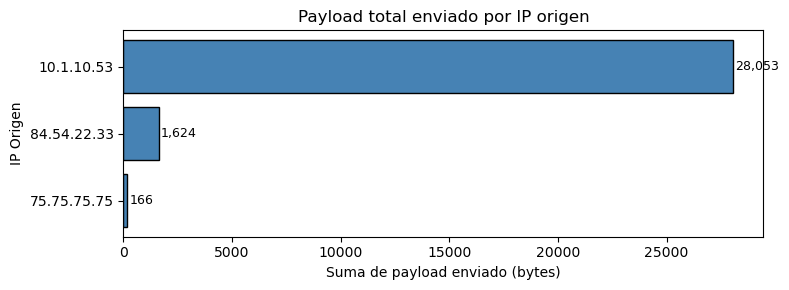

In [13]:
src_payload = df.groupby('src_ip')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(src_payload.index, src_payload.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Suma de payload enviado (bytes)')
ax.set_ylabel('IP Origen')
ax.set_title('Payload total enviado por IP origen')
for v, ip in zip(src_payload.values, src_payload.index):
    ax.text(v + 100, ip, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 5b. Payload total recibido por IP destino

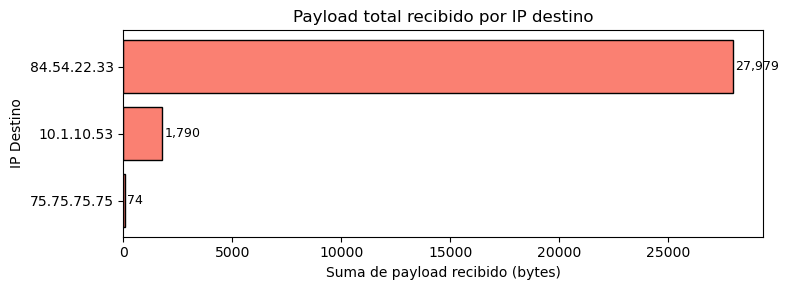

In [14]:
dst_payload = df.groupby('dst_ip')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(dst_payload.index, dst_payload.values, color='salmon', edgecolor='black')
ax.set_xlabel('Suma de payload recibido (bytes)')
ax.set_ylabel('IP Destino')
ax.set_title('Payload total recibido por IP destino')
for v, ip in zip(dst_payload.values, dst_payload.index):
    ax.text(v + 100, ip, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 5c. Payload total enviado por puerto origen

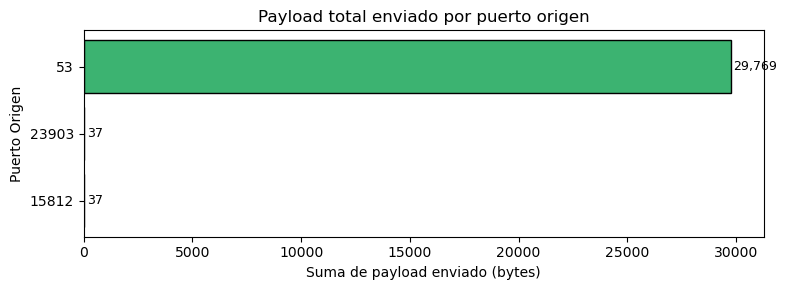

In [15]:
sport_payload = df.groupby('src_port')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(sport_payload.index.astype(str), sport_payload.values, color='mediumseagreen', edgecolor='black')
ax.set_xlabel('Suma de payload enviado (bytes)')
ax.set_ylabel('Puerto Origen')
ax.set_title('Payload total enviado por puerto origen')
for v, p in zip(sport_payload.values, sport_payload.index.astype(str)):
    ax.text(v + 100, p, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 5d. Payload total recibido por puerto destino

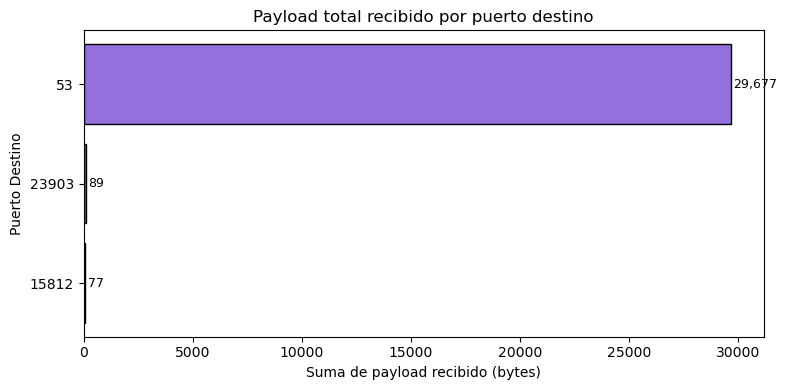

In [16]:
dport_payload = df.groupby('dst_port')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(dport_payload.index.astype(str), dport_payload.values, color='mediumpurple', edgecolor='black')
ax.set_xlabel('Suma de payload recibido (bytes)')
ax.set_ylabel('Puerto Destino')
ax.set_title('Payload total recibido por puerto destino')
for v, p in zip(dport_payload.values, dport_payload.index.astype(str)):
    ax.text(v + 100, p, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
### 6. Detección automática con Isolation Forest
#### 6a. Entrenamiento y anomalías detectadas

El parámetro `contamination` se calcula como la proporción de anomalías detectadas en el inciso 4c sobre el total de paquetes: **30 / 62 ≈ 0.484**.

In [17]:
n_anomalies  = len(anomalias_domain)
n_total      = len(df)
contamination = n_anomalies / n_total

features   = df[['payload_len', 'pkt_len']].fillna(0)
iso_forest = IsolationForest(contamination=contamination, random_state=42)
df['iso_pred'] = iso_forest.fit_predict(features)  # -1 = anomalía

anomalias_iso = df[df['iso_pred'] == -1]
anomalias_iso[['src_ip','dst_ip','src_port','dst_port','payload_len','pkt_len']]

,src_ip,dst_ip,src_port,dst_port,payload_len,pkt_len
0,10.1.10.53,84.54.22.33,53,53,933,975
2,10.1.10.53,84.54.22.33,53,53,947,989
4,10.1.10.53,84.54.22.33,53,53,984,1026
6,10.1.10.53,84.54.22.33,53,53,970,1012
8,10.1.10.53,84.54.22.33,53,53,975,1017
10,10.1.10.53,84.54.22.33,53,53,1017,1059
12,10.1.10.53,84.54.22.33,53,53,980,1022
14,10.1.10.53,84.54.22.33,53,53,951,993
16,10.1.10.53,84.54.22.33,53,53,931,973
18,10.1.10.53,84.54.22.33,53,53,964,1006


Isolation Forest marcó exactamente **30 paquetes como anomalías**, todas provenientes de la conversación `10.1.10.53 ↔ 84.54.22.33` y de las dos consultas menores hacia `75.75.75.75`.

#### 6b. Comparación con los Z-score

In [18]:
from IPython.display import display
display(anomalias_iso[['src_ip','dst_ip']].value_counts().rename('isolation_forest'))
anomalias_domain[['src_ip','dst_ip']].value_counts().rename('z_score_domain')

src_ip       dst_ip     
10.1.10.53   84.54.22.33    26
             75.75.75.75     2
75.75.75.75  10.1.10.53      2
Name: isolation_forest, dtype: int64

src_ip       dst_ip     
10.1.10.53   84.54.22.33    29
75.75.75.75  10.1.10.53      1
Name: z_score_domain, dtype: int64

**Sí coinciden.** Ambos métodos señalan la conversación `10.1.10.53 → 84.54.22.33` como la principal fuente de tráfico anómalo.

- El **Z-score con baseline DNS** requirió conocimiento previo del protocolo para funcionar.
- **Isolation Forest** detectó los outliers de forma puramente multidimensional (`payload_len` + `pkt_len`), sin ningún conocimiento del protocolo.

La convergencia de ambos métodos independientes aumenta significativamente la confianza en la detección.

---
### 7. Investigación del payload (confirmación manual)
#### 7a. Conexiones con la IP origen más frecuente

In [19]:
df_src_freq = df[df['src_ip'] == most_freq_src].copy()
df_src_freq.drop(columns='payload_raw').head()

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len,zscore_pcap,zscore_domain,iso_pred
0,10.1.10.53,84.54.22.33,53,53,975,933,0.981296,58.866667,-1
2,10.1.10.53,84.54.22.33,53,53,989,947,1.011713,59.800000,-1
4,10.1.10.53,84.54.22.33,53,53,1026,984,1.092101,62.266667,-1
6,10.1.10.53,84.54.22.33,53,53,1012,970,1.061684,61.333333,-1
8,10.1.10.53,84.54.22.33,53,53,1017,975,1.072547,61.666667,-1


31 paquetes originados desde `10.1.10.53`.

#### 7b. Agrupado por `src_ip`, `dst_ip` y suma de payload

In [20]:
df_grouped = (
    df_src_freq
    .groupby(['src_ip', 'dst_ip'])['payload_len']
    .sum()
    .reset_index()
    .rename(columns={'payload_len': 'total_payload_bytes'})
)
df_grouped

,src_ip,dst_ip,total_payload_bytes
0,10.1.10.53,75.75.75.75,74
1,10.1.10.53,84.54.22.33,27979


#### 7c. IP que más bytes intercambió con la IP más frecuente

In [21]:
top_pair     = df_grouped.sort_values('total_payload_bytes', ascending=False).iloc[0]
suspicious_ip = top_pair['dst_ip']
df_grouped.sort_values('total_payload_bytes', ascending=False)

,src_ip,dst_ip,total_payload_bytes
1,10.1.10.53,84.54.22.33,27979
0,10.1.10.53,75.75.75.75,74


La IP que más bytes intercambió con `10.1.10.53` es **`84.54.22.33`** con **27,979 bytes** enviados — frente a apenas 74 bytes hacia `75.75.75.75`. Esto coincide exactamente con la IP sospechosa identificada por Z-score e Isolation Forest.

#### 7d. Conversación entre `10.1.10.53` y `84.54.22.33`

In [22]:
df_conv = df[
    ((df['src_ip'] == most_freq_src) & (df['dst_ip'] == suspicious_ip)) |
    ((df['src_ip'] == suspicious_ip) & (df['dst_ip'] == most_freq_src))
].copy()

df_conv.drop(columns='payload_raw').head(10)

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len,zscore_pcap,zscore_domain,iso_pred
0,10.1.10.53,84.54.22.33,53,53,975,933,0.981296,58.866667,-1
1,84.54.22.33,10.1.10.53,53,53,98,56,-0.924107,0.400000,1
2,10.1.10.53,84.54.22.33,53,53,989,947,1.011713,59.800000,-1
3,84.54.22.33,10.1.10.53,53,53,98,56,-0.924107,0.400000,1
4,10.1.10.53,84.54.22.33,53,53,1026,984,1.092101,62.266667,-1
5,84.54.22.33,10.1.10.53,53,53,98,56,-0.924107,0.400000,1
6,10.1.10.53,84.54.22.33,53,53,1012,970,1.061684,61.333333,-1
7,84.54.22.33,10.1.10.53,53,53,98,56,-0.924107,0.400000,1
8,10.1.10.53,84.54.22.33,53,53,1017,975,1.072547,61.666667,-1
9,84.54.22.33,10.1.10.53,53,53,98,56,-0.924107,0.400000,1


La conversación entre ambas IPs comprende **58 paquetes**: 29 consultas (payloads de ~950 bytes) y 29 respuestas (payloads de 56 bytes).

#### 7e & 7f. Payloads extraídos — contenido del primer array

In [23]:
payloads = [p for p in df_conv['payload_raw'].tolist() if p]
first    = payloads[0]

readable = ''.join(chr(b) if 32 <= b < 127 else '.' for b in first)
readable[:200]

'.............google.com........PNG........IHDR...b...........(...TR..:...IDATx.......|T...............;K..;.....E......$.......Zi..-...;N2......V...V...a...Z.!.........ik[....ok...e....\\......]...-...'

Se extrajeron **58 payloads**. El primer payload tiene **933 bytes**. En su representación ASCII ya se distingue la cadena `google.com` seguida de `PNG`, `IHDR`, `IDATx` — marcadores propios de una imagen PNG incrustada dentro de un paquete DNS.

#### 7g. Confirmación del tipo de ataque

In [24]:
PNG_MAGIC = bytes([0x89, 0x50, 0x4E, 0x47, 0x0D, 0x0A, 0x1A, 0x0A])  # \x89PNG\r\n\x1a\n
idx = first.find(b'PNG')

pd.DataFrame([
    {"Campo": "Payloads que contienen datos PNG",   "Valor": f"{sum(1 for p in payloads if b'PNG' in p)} de {len(payloads)}"},
    {"Campo": "Offset de 'PNG' en el primer payload", "Valor": f"byte {idx}"},
    {"Campo": "Bytes desde el offset (hex)",          "Valor": first[idx:idx+8].hex()},
    {"Campo": "Bytes desde el offset (texto)",        "Valor": str(first[idx:idx+8])},
])

,Campo,Valor
0,Payloads que contienen datos PNG,1 de 58
1,Offset de 'PNG' en el primer payload,byte 31
2,Bytes desde el offset (hex),504e470d0a1a0a00
3,Bytes desde el offset (texto),b'PNG\r\n\x1a\n\x00'


### Ataque identificado: **DNS Tunneling** (exfiltración de datos por DNS)

**Evidencia:**
- El puerto usado es el **53 (DNS)**, protocolo casi universalmente permitido en firewalls.
- Una consulta DNS normal mide ~50 bytes. Los payloads capturados miden entre **931 y 1026 bytes** — 18–20× más de lo esperado.
- Los payloads contienen la firma mágica de un archivo PNG (`PNG`, `IHDR`, `IDAT`) incrustada en paquetes que aparentan ser consultas DNS a `google.com`.

**Descripción del ataque:**  
La máquina `10.1.10.53` exfiltra archivos de imagen (PNG) al host externo `84.54.22.33` ocultando el contenido dentro del campo de datos de paquetes DNS. Esta técnica elude controles de seguridad que no realizan *deep packet inspection* sobre el protocolo DNS.

**¿Por qué es importante combinar técnicas automáticas con inspección manual del payload?**  
- Isolation Forest y el Z-score con baseline identificaron qué tráfico era estadísticamente anómalo, reduciendo 62 paquetes a un subconjunto manejable de 30 sospechosos.
- Sin la inspección manual de los bytes, el tráfico podría confundirse con un software mal configurado o un error de implementación DNS.
- Solo la combinación de ambos enfoques permite **confirmar con certeza el tipo de ataque** y diseñar una respuesta adecuada (bloqueo de la IP, análisis forense, alertas).

---
## Resumen del laboratorio

| Técnica | Resultado |
|---|---|
| Z-Score (estadísticas del pcap) | **0 anomalías** — distribución bimodal contamina los parámetros |
| Z-Score (baseline DNS μ=50, σ=15) | **30 paquetes anómalos** detectados |
| Isolation Forest (contamination=0.484) | **30 paquetes anómalos** — coincide con Z-score |
| Inspección manual del payload | **DNS Tunneling** confirmado: imágenes PNG exfiltradas vía puerto 53 |

| Rol | IP |
|---|---|
| Máquina interna (atacante/infectada) | `10.1.10.53` |
| Servidor externo (C2 / receptor) | `84.54.22.33` |
| Protocolo abusado | DNS — Puerto 53 |